# Effectiveness of thrombolysis in early (4hr) arrivals of mild stroke - discharge mRS 0-2: Target trial emulation

## Selection criteria

* Arrival within 4 hours of known stroke onset time
* No thrombectomy
* Stroke type = infarction
* No recorded use of perfusion imaging
* Stroke severity 1-5

## Outcome of interest

* Discharge mRS 0-2.

## Key features of interest

* Onset to thrombolysis time

## Adjustment features used:

* Prior disability
* Stroke severity
* Age
* Congestive heart failure
* Hypertension
* Diabetes
* Atrial fibrillation anticoagulant
* Any atrial fibrillation diagnosis (existing or new)
* Stroke team
* Ethnicity

## Target trial emulation

See: https://www.nice.org.uk/corporate/ecd9/chapter/overview

Hernán MA, Dahabreh IJ, Dickerman BA, Swanson SA. The Target Trial Framework for Causal Inference From Observational Data: Why and When Is It Helpful? Ann Intern Med. 2025 Mar;178(3):402-407. doi: 10.7326/ANNALS-24-01871.

Cashin, A. G.; Hansford, H. J.; Hernán, M. A.; Swanson, S. A.; Lee, H.; Jones, M. D.; Dahabreh, I. J.; Dickerman, B. A.; Egger, M.; Garcia-Albeniz, X.; Golub, R. M.; Islam, N.; Lodi, S.; Moreno-Betancur, M.; Pearson, S.-A.; Schneeweiss, S.; Sharp, M. K.; Sterne, J. A. C.; Stuart, E. A.; McAuley, J. H. Transparent Reporting of Observational Studies Emulating a Target Trial—The TARGET Statement. 

JAMA 2025, 334 (12), 1084–1093. https://doi.org/10.1001/jama.2025.13350

BMJ 2025. https://doi.org/10.1136/bmj-2025-087179

YouTube videos on Target Trial Emulation:

https://www.youtube.com/watch?v=eWImwOCZndU

https://www.youtube.com/watch?v=UhmW4U_9vvA

## Load modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


# Disable warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

## Define mRS outcome target & time cut-off

In [2]:
mrs_target = 2 # Model will set y as being less than or equal to this value

time_cutoff = 180

## Load and filter data

In [3]:
data = pd.read_csv("../../data/sam3/cleaned_data_anon_teams.csv", low_memory=False)

print(f"Initial data shape: {data.shape}")

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only infarction cases
data = data[data["infarction"] == 1]

# Keep only onset to arrival < 240 mins
data = data[data["onset_to_arrival_time"] < 240]

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only perfusion_imaging_used == 0
data = data[data["perfusion_imaging_used"] == 0]

# Exlude patients who received thrombectomy
data = data[data["thrombectomy"] == 0]

# Limit to stroke severity  1 - 5 
data = data[(data["stroke_severity"] >= 1) & (data["stroke_severity"] <= 5)]

# Keep only teams with at least 10 onset_to_thrombolysis_time
team_counts = data.groupby("stroke_team")["onset_to_thrombolysis_time"].count()
valid_teams = team_counts[team_counts >= 10].index
data = data[data["stroke_team"].isin(valid_teams)]

# Missing treatment times -> sentinel
data["onset_to_thrombolysis_time"] = data["onset_to_thrombolysis_time"].fillna(99999)

# Exclude late thrombolysis (> 360) unless sentinel
data = data[
    (data["onset_to_thrombolysis_time"] <= 360)
    | (data["onset_to_thrombolysis_time"] == 99999)
]

# Add mrs less than threshold
data['outcome_target'] = (data['discharge_disability'] <= mrs_target).astype(int)

print(f"Final data shape: {data.shape}")

# Treatment counts
num_thrombolysis = (data["onset_to_thrombolysis_time"] != 99999).sum()
print(f"Number of patients with thrombolysis: {num_thrombolysis}")


Initial data shape: (452863, 72)
Final data shape: (58389, 73)
Number of patients with thrombolysis: 13380


Add time labels.

In [4]:
data.loc[data["onset_to_thrombolysis_time"] <= 180, "treatment_group"] = "<180 min"
data.loc[(data["onset_to_thrombolysis_time"] > 180) & (data["onset_to_thrombolysis_time"] <= 270), "treatment_group"] = "180-270 min"
data.loc[(data["onset_to_thrombolysis_time"] > 270) & (data["onset_to_thrombolysis_time"] <= 360), "treatment_group"] = "270-360 min"
data.loc[data["onset_to_thrombolysis_time"] == 99999, "treatment_group"] = "No thrombolysis"


In [5]:
DESCRIPTIVE_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'length_of_stay',
    'discharge_disability',
    'outcome_target',
    'thrombolysis_induced_haemorrhage',
    'death',
]

MATCHING_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'afib_anticoagulant',
    'any_afib_diagnosis'
]

ALL_FEATURES = list(set(DESCRIPTIVE_FEATURES + ['onset_to_thrombolysis_time']))

## Matching

In [6]:
control_group_name = "No thrombolysis"
treatment_groups = sorted(
    group for group in data["treatment_group"].dropna().unique()
    if group != control_group_name
)

matched_samples = {}
summary_rows = []
summary_rows_target = []

for group_name in treatment_groups:
    treated_group = data[data["treatment_group"] == group_name]
    untreated_group = data[data["treatment_group"] == control_group_name]

    if treated_group.empty or untreated_group.empty:
        continue

    target_treated = []
    target_untreated = []
    count = 0
    matched = 0
    unmatched = 0

    while count < len(treated_group):
        # Get a treated patient using the count as index to ensure we sample each treated patient in order
        treated_patient = treated_group.iloc[[count]]
        treated_row = treated_patient.iloc[0]
        count += 1

        matching_untreated = untreated_group
        for feature_name in MATCHING_FEATURES:
            matching_untreated = matching_untreated[
                matching_untreated[feature_name] == treated_row[feature_name]
            ]

        if len(matching_untreated) > 0:
            untreated_patient = matching_untreated.sample(
                n=1, random_state=42 + count
            )
            target_treated.append(treated_patient)
            target_untreated.append(untreated_patient)
            matched += 1
        else:
            unmatched += 1

    percent_matched = 100 * matched / (matched + unmatched)

    target_treated_df = pd.concat(target_treated).reset_index(drop=True)
    target_untreated_df = pd.concat(target_untreated).reset_index(drop=True)

    matched_samples[group_name] = {
        "treated": target_treated_df,
        "untreated": target_untreated_df,
    }

    # Summary for discharge_disability
    treated_mean = target_treated_df["discharge_disability"].mean()
    untreated_mean = target_untreated_df["discharge_disability"].mean()
    treated_ci = sm.stats.DescrStatsW(
        target_treated_df["discharge_disability"]
    ).tconfint_mean(alpha=0.05)
    untreated_ci = sm.stats.DescrStatsW(
        target_untreated_df["discharge_disability"]
    ).tconfint_mean(alpha=0.05)
    ttest_result = sm.stats.ttest_ind(
        target_treated_df["discharge_disability"],
        target_untreated_df["discharge_disability"],
    )
    t_stat, p_value = ttest_result[0], ttest_result[1]

    summary_rows.append({
        "treatment_group": group_name,
        "matched_n": matched,
        "percent_matched": percent_matched,
        "treated_mean": treated_mean,
        "treated_ci_lower": treated_ci[0],
        "treated_ci_upper": treated_ci[1],
        "untreated_mean": untreated_mean,
        "untreated_ci_lower": untreated_ci[0],
        "untreated_ci_upper": untreated_ci[1],
        "t_stat": t_stat,
        "p_value": p_value,
    })

    # Summary for outcome_target
    treated_mean_t = target_treated_df["outcome_target"].mean()
    untreated_mean_t = target_untreated_df["outcome_target"].mean()
    treated_ci_t = sm.stats.DescrStatsW(
        target_treated_df["outcome_target"]
    ).tconfint_mean(alpha=0.05)
    untreated_ci_t = sm.stats.DescrStatsW(
        target_untreated_df["outcome_target"]
    ).tconfint_mean(alpha=0.05)
    ttest_result_t = sm.stats.ttest_ind(
        target_treated_df["outcome_target"],
        target_untreated_df["outcome_target"],
    )
    t_stat_t, p_value_t = ttest_result_t[0], ttest_result_t[1]

    summary_rows_target.append({
        "treatment_group": group_name,
        "matched_n": matched,
        "percent_matched": percent_matched,
        "treated_mean": treated_mean_t,
        "treated_ci_lower": treated_ci_t[0],
        "treated_ci_upper": treated_ci_t[1],
        "untreated_mean": untreated_mean_t,
        "untreated_ci_lower": untreated_ci_t[0],
        "untreated_ci_upper": untreated_ci_t[1],
        "t_stat": t_stat_t,
        "p_value": p_value_t,
    })

In [7]:
summary_df = pd.DataFrame(summary_rows).sort_values("p_value")
summary_df["mean_difference_improvement"] = 0 - (
    summary_df["treated_mean"] - summary_df["untreated_mean"]
)

summary_df_target = pd.DataFrame(summary_rows_target).sort_values("p_value")
summary_df_target["mean_difference_improvement"] = (
    summary_df_target["treated_mean"] - summary_df_target["untreated_mean"]
)

# Make new cols for publishing means and CIs
summary_df["treated_mean_publish"] = summary_df["treated_mean"]
summary_df["untreated_mean_publish"] = summary_df["untreated_mean"]
summary_df_target["treated_mean_publish"] = summary_df_target["treated_mean"]
summary_df_target["untreated_mean_publish"] = summary_df_target["untreated_mean"]

# Format results as mean plus/minus confidence interval and P-value
summary_df["treated_mean_publish"] = summary_df.apply(
    lambda row: f"{row['treated_mean_publish']:.2f} ({row['treated_ci_lower']:.2f}, {row['treated_ci_upper']:.2f})", axis=1
)
summary_df["untreated_mean_publish"] = summary_df.apply(
    lambda row: f"{row['untreated_mean_publish']:.2f} ({row['untreated_ci_lower']:.2f}, {row['untreated_ci_upper']:.2f})", axis=1
)
summary_df["p_value"] = summary_df["p_value"].apply(lambda p: f"{p:.3f}")
summary_df_target["treated_mean_publish"] = summary_df_target.apply(
    lambda row: f"{row['treated_mean_publish']:.2f} ({row['treated_ci_lower']:.2f}, {row['treated_ci_upper']:.2f})", axis=1
)
summary_df_target["untreated_mean_publish"] = summary_df_target.apply(
    lambda row: f"{row['untreated_mean_publish']:.2f} ({row['untreated_ci_lower']:.2f}, {row['untreated_ci_upper']:.2f})", axis=1
)

row_order = [
    'No thrombolysis',
    '<180 min',
    '180-270 min',
    '270-360 min',
]

# Sort summary_df and summary_df_target by row_order
summary_df["treatment_group"] = pd.Categorical(summary_df["treatment_group"], categories=row_order, ordered=True)
summary_df = summary_df.sort_values("treatment_group")
summary_df_target["treatment_group"] = pd.Categorical(summary_df_target["treatment_group"], categories=row_order, ordered=True)
summary_df_target = summary_df_target.sort_values("treatment_group")

# Replace _ with spaces in treatment_group for better display
summary_df["treatment_group"] = summary_df["treatment_group"].str.replace("_", " ")
summary_df_target["treatment_group"] = summary_df_target["treatment_group"].str.replace("_", " ")

print("=== discharge_disability ===")
display(summary_df)
print("=== outcome_target ===")
display(summary_df_target)

# Save to CSV
summary_df.to_csv("./output/target_trial_emulation_summary_discharge_disability.csv", index=False)
summary_df_target.to_csv(f"./output/target_trial_emulation_summary_outcome_target_{mrs_target}.csv", index=False)



=== discharge_disability ===


,treatment_group,matched_n,percent_matched,treated_mean,treated_ci_lower,treated_ci_upper,untreated_mean,untreated_ci_lower,untreated_ci_upper,t_stat,p_value,mean_difference_improvement,treated_mean_publish,untreated_mean_publish
2,<180 min,7378,99.837618,1.680808,1.650053,1.711563,1.898482,1.866795,1.930169,-9.663132,0.000,0.217674,"1.68 (1.65, 1.71)","1.90 (1.87, 1.93)"
0,180-270 min,5512,99.963729,1.792453,1.755504,1.829401,1.924891,1.887795,1.961987,-4.958831,0.000,0.132438,"1.79 (1.76, 1.83)","1.92 (1.89, 1.96)"
1,270-360 min,475,99.789916,1.701053,1.568824,1.833282,1.791579,1.664049,1.919108,-0.968295,0.333,0.090526,"1.70 (1.57, 1.83)","1.79 (1.66, 1.92)"


=== outcome_target ===


,treatment_group,matched_n,percent_matched,treated_mean,treated_ci_lower,treated_ci_upper,untreated_mean,untreated_ci_lower,untreated_ci_upper,t_stat,p_value,mean_difference_improvement,treated_mean_publish,untreated_mean_publish
2,<180 min,7378,99.837618,0.753727,0.743894,0.763560,0.684738,0.674134,0.695343,9.351459,9.864604e-21,0.068989,"0.75 (0.74, 0.76)","0.68 (0.67, 0.70)"
0,180-270 min,5512,99.963729,0.720428,0.708577,0.732280,0.674528,0.662155,0.686902,5.251829,1.534017e-07,0.045900,"0.72 (0.71, 0.73)","0.67 (0.66, 0.69)"
1,270-360 min,475,99.789916,0.751579,0.712580,0.790578,0.713684,0.672886,0.754483,1.319330,1.873773e-01,0.037895,"0.75 (0.71, 0.79)","0.71 (0.67, 0.75)"


## Descriptive statistics

In [8]:
# Provide descriptive statistics for the matched samples
# Concatenate all descriptive stats into a single DataFrame for easier display

descriptive_stats = []
for group_name, samples in matched_samples.items():
    treated_df = samples["treated"]
    untreated_df = samples["untreated"]

    for feature in DESCRIPTIVE_FEATURES:
        treated_mean = treated_df[feature].mean()
        treated_std = treated_df[feature].std()
        untreated_mean = untreated_df[feature].mean()
        untreated_std = untreated_df[feature].std()

        descriptive_stats.append({
            "treatment_group": group_name,
            "feature": feature,
            "treated_n": treated_df[feature].notna().sum(),
            "treated_mean": treated_mean,
            "treated_std": treated_std,
            "untreated_n": untreated_df[feature].notna().sum(),
            "untreated_mean": untreated_mean,
            "untreated_std": untreated_std
        })
descriptive_stats_df = pd.DataFrame(descriptive_stats)
descriptive_stats_df["treatment_group"] = pd.Categorical(descriptive_stats_df["treatment_group"], categories=row_order, ordered=True)

# Save to output CSV
descriptive_stats_df.to_csv("output/descriptive_stats_target_trial.csv", index=False)

descriptive_stats_df.round(3)


,treatment_group,feature,treated_n,treated_mean,treated_std,untreated_n,untreated_mean,untreated_std
0,180-270 min,prior_disability,5512,0.568,0.966,5512,0.568,0.966
1,180-270 min,stroke_severity,5512,3.643,1.215,5512,3.643,1.215
2,180-270 min,age,5512,70.554,13.267,5512,70.554,13.267
3,180-270 min,congestive_heart_failure,5512,0.036,0.187,5512,0.040,0.197
4,180-270 min,hypertension,5512,0.531,0.499,5512,0.549,0.498
5,180-270 min,diabetes,5512,0.204,0.403,5512,0.218,0.413
6,180-270 min,afib_anticoagulant,5512,0.023,0.151,5512,0.023,0.151
7,180-270 min,any_afib_diagnosis,5512,0.121,0.326,5512,0.121,0.326
8,180-270 min,length_of_stay,5512,10.705,20.170,5511,12.585,22.091
9,180-270 min,discharge_disability,5512,1.792,1.399,5512,1.925,1.405


## Plot

In [9]:
# Calculate length-of-stay statistics after removing incomplete matched pairs
length_of_stay_results = []

for group_name, samples in matched_samples.items():
    treated = samples["treated"].reset_index(drop=True)
    untreated = samples["untreated"].reset_index(drop=True)

    valid = (
        treated["length_of_stay"].notna()
        & untreated["length_of_stay"].notna()
    )

    treated_los = pd.to_numeric(
        treated.loc[valid, "length_of_stay"], errors="coerce"
    ).dropna()

    untreated_los = pd.to_numeric(
        untreated.loc[valid, "length_of_stay"], errors="coerce"
    ).dropna()

    if len(treated_los) == 0:
        continue

    treated_ci = sm.stats.DescrStatsW(treated_los).tconfint_mean(alpha=0.05)
    untreated_ci = sm.stats.DescrStatsW(untreated_los).tconfint_mean(alpha=0.05)

    t_stat, p_value, _ = sm.stats.ttest_ind(
        treated_los,
        untreated_los,
    )

    length_of_stay_results.append({
        "treatment_group": group_name,
        "matched_n": len(treated_los),
        "treated_mean": treated_los.mean(),
        "treated_ci_lower": treated_ci[0],
        "treated_ci_upper": treated_ci[1],
        "untreated_mean": untreated_los.mean(),
        "untreated_ci_lower": untreated_ci[0],
        "untreated_ci_upper": untreated_ci[1],
        "t_stat": t_stat,
        "p_value": p_value,
    })

length_of_stay_df = (
    pd.DataFrame(length_of_stay_results)
    .sort_values("treatment_group")
    .reset_index(drop=True)
)

length_of_stay_df

,treatment_group,matched_n,treated_mean,treated_ci_lower,treated_ci_upper,untreated_mean,untreated_ci_lower,untreated_ci_upper,t_stat,p_value
0,180-270 min,5511,10.706042,10.173352,11.238733,12.585193,12.001811,13.168575,-4.663158,3.150525e-06
1,270-360 min,475,9.917895,8.326632,11.509157,11.480000,9.449002,13.510998,-1.189672,2.344732e-01
2,<180 min,7378,8.965302,8.539637,9.390967,12.147059,11.665754,12.628363,-9.707176,3.274695e-22


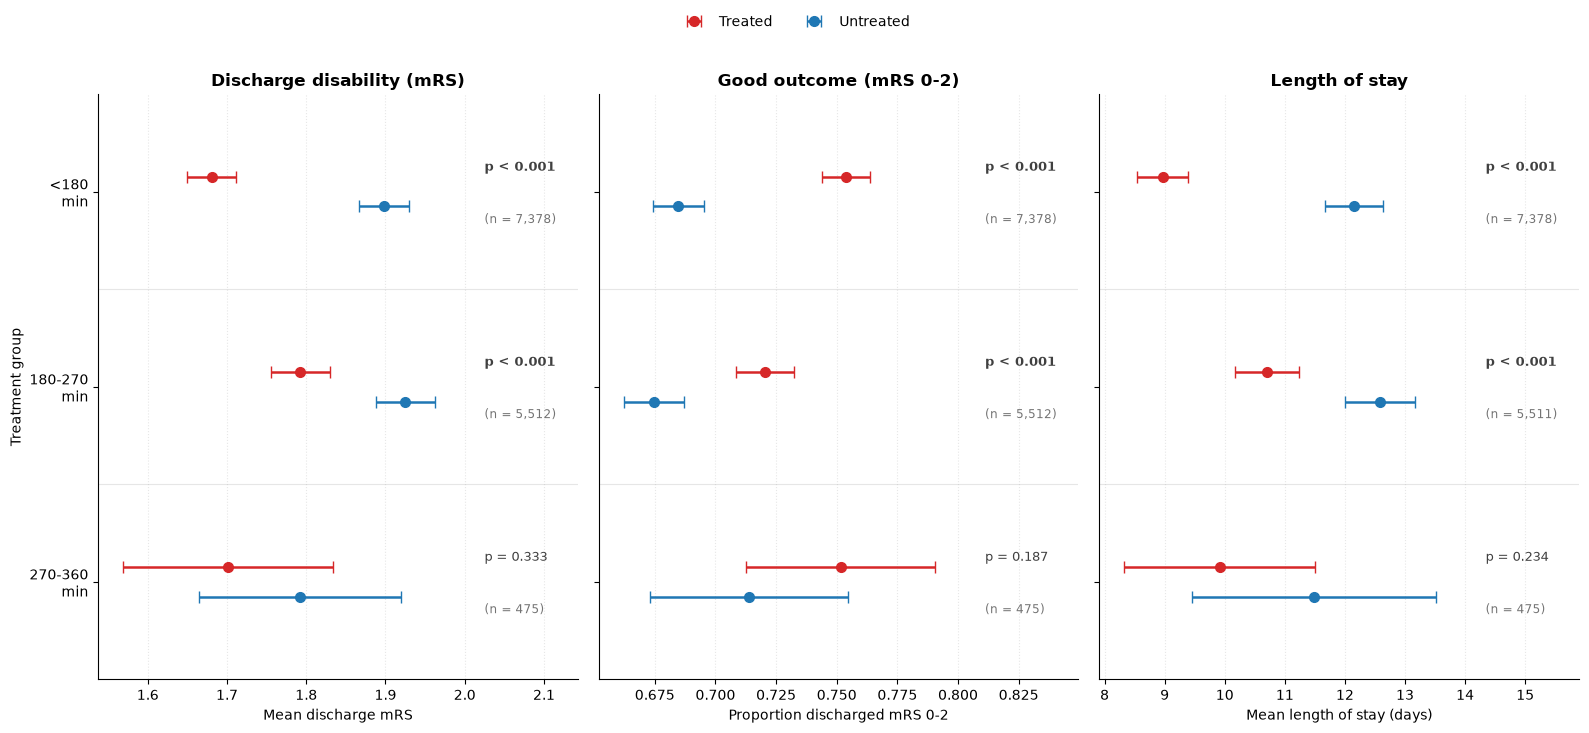

In [13]:
panels = [
    (summary_df.copy(), "Discharge disability (mRS)", "Mean discharge mRS"),
    (summary_df_target.copy(), "Good outcome (mRS 0-2)",
     f"Proportion discharged mRS 0-{mrs_target}"),
    (length_of_stay_df.copy(), "Length of stay", "Mean length of stay (days)"),
]

C_T, C_U = "#d62728", "#1f77b4"
OFF = 0.18
SPACING = 2.4

fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=True)

for ax, (df, title, xlabel) in zip(axes, panels):
    df["treatment_group"] = pd.Categorical(
        df["treatment_group"],
        categories=row_order,
        ordered=True,
    )
    df = df.sort_values("treatment_group").iloc[::-1].reset_index(drop=True)

    y = np.arange(len(df), dtype=float) * SPACING
    labels = [str(group).replace(" ", "\n", 1) for group in df["treatment_group"]]

    for suffix, offset, colour, label in [
        ("treated", OFF, C_T, "Treated"),
        ("untreated", -OFF, C_U, "Untreated"),
    ]:
        mean = np.asarray(df[f"{suffix}_mean"], dtype=float)
        lower = np.asarray(df[f"{suffix}_ci_lower"], dtype=float)
        upper = np.asarray(df[f"{suffix}_ci_upper"], dtype=float)

        ax.errorbar(
            mean,
            y + offset,
            xerr=[mean - lower, upper - mean],
            fmt="o",
            color=colour,
            ecolor=colour,
            markersize=7,
            capsize=4,
            elinewidth=1.8,
            label=label,
            zorder=3,
        )

    xmax = max(
        pd.to_numeric(df["treated_ci_upper"]).max(),
        pd.to_numeric(df["untreated_ci_upper"]).max(),
    )
    xmin = min(
        pd.to_numeric(df["treated_ci_lower"]).min(),
        pd.to_numeric(df["untreated_ci_lower"]).min(),
    )
    span = max(xmax - xmin, 1e-9)
    xtext = xmax + 0.16 * span

    for yi, p_value, n in zip(y, df["p_value"], df["matched_n"]):
        p_num = float(pd.to_numeric(p_value, errors="coerce"))
        p_text = "p < 0.001" if p_num < 0.001 else f"p = {p_num:.3f}"

        ax.text(
            xtext, yi + 0.30, p_text,
            va="center", ha="left", fontsize=9,
            fontweight="bold" if p_num < 0.05 else "normal",
            color="0.25",
        )
        ax.text(
            xtext, yi - 0.34, f"(n = {int(n):,})",
            va="center", ha="left", fontsize=8.5, color="0.45",
        )

    ax.set_xlim(xmin - 0.08 * span, xtext + 0.30 * span)

    for yi in y[:-1]:
        ax.axhline(yi + SPACING / 2, color="0.9", lw=0.8, zorder=0)

    ax.set_ylim(y[0] - SPACING / 2, y[-1] + SPACING / 2)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="x", alpha=0.3, linestyle=":")
    ax.set_axisbelow(True)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("Treatment group")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.92),
)

fig.tight_layout(rect=(0, 0.05, 1, 0.90))
fig.savefig(f"./output/target_trial_emulation_mrs_{mrs_target}.png", dpi=300)
plt.show()